Cargar Librerías y Dataset

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from pycaret.classification import *

# 1. Cargar el dataset Fashion-MNIST
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Definir los Nombres de las Clases

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Número de imágenes de entrenamiento: {train_images.shape[0]}")
print(f"Dimensiones de cada imagen: {train_images.shape[1:]}") #28px x 28px

Número de imágenes de entrenamiento: 60000
Dimensiones de cada imagen: (28, 28)


Preparación de Datos (Normalización)

In [ ]:
# Reducir la cantidad de datos
train_images = train_images[:10000]
train_labels = train_labels[:10000]
test_images = test_images[:5000]
test_labels = test_labels[:5000]

#Normalizar las imágenes (escalar valores de 0-255 a 0-1)
train_images = train_images / 255.0
test_images = test_images / 255.0

#Ajustar dimensiones para CNN (añadir un canal para escala de grises)
# (60000, 28, 28) -> (60000, 28, 28, 1)
train_images = np.expand_dims(train_images, -1)
test_images = np.expand_dims(test_images, -1)

Codificación One-Hot (Etiquetas)

In [ ]:
#Las redes neuronales necesitan que las etiquetas de clase (0, 1, 2,...)
#se conviertan a un formato binario llamado one-hot encoding
num_classes = len(class_names)

train_labels_one_hot = to_categorical(train_labels, num_classes=num_classes)
test_labels_one_hot = to_categorical(test_labels, num_classes=num_classes)

Desarrollo del Modelo (CNN)

In [ ]:
#Definir el modelo secuencial (Sequential)
model = Sequential([
    # Capa 1: Convolución (32 filtros)
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Capa 2: Agrupamiento máximo (MaxPooling)
    MaxPooling2D((2, 2)),

    # Aplanar los datos 2D a un vector 1D para las capas densas
    Flatten(),

    # Capa 3: Densa (totalmente conectada)
    Dense(128, activation='relu'),

    # Capa 4: Capa de salida. 10 neuronas (una por clase) con activación softmax
    Dense(num_classes, activation='softmax')
])

#Compilar el modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy', # Usamos esta pérdida por el One-Hot Encoding
              metrics=['accuracy'])

Entrenamiento del Modelo

In [ ]:
#Entrenamiento del modelo
#Utiliza el 10% de los datos de entrenamiento como conjunto de validación
history = model.fit(train_images, train_labels_one_hot,
                    epochs=10,
                    validation_split=0.1,
                    batch_size=32)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6778 - loss: 0.9029 - val_accuracy: 0.8310 - val_loss: 0.4804
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8614 - loss: 0.4010 - val_accuracy: 0.8700 - val_loss: 0.3938
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8803 - loss: 0.3455 - val_accuracy: 0.8740 - val_loss: 0.4026
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9019 - loss: 0.2806 - val_accuracy: 0.8800 - val_loss: 0.3666
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9171 - loss: 0.2471 - val_accuracy: 0.8840 - val_loss: 0.3421
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9339 - loss: 0.2091 - val_accuracy: 0.8870 - val_loss: 0.3385
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9373 - loss: 0.1840 - val_accuracy: 0.8920 - val_loss: 0.3488
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9432 - loss: 0.1681 - val_accu

Evaluación del Modelo

In [ ]:
print("\n--- Evaluación del Modelo en Datos de Prueba ---")
test_loss, test_acc = model.evaluate(test_images,  test_labels_one_hot, verbose=2)

print(f"\nPérdida (Loss) en el conjunto de prueba: {test_loss:.4f}")
print(f"Precisión (Accuracy) en el conjunto de prueba: {test_acc:.4f}")


--- Evaluación del Modelo en Datos de Prueba ---
157/157 - 1s - 7ms/step - accuracy: 0.8716 - loss: 0.3967

Pérdida (Loss) en el conjunto de prueba: 0.3967
Precisión (Accuracy) en el conjunto de prueba: 0.8716


Predicción con Nuevos Datos

In [ ]:
# Realizar predicciones en el conjunto de prueba
# Las predicciones son un array de probabilidades para cada clase.
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])

# Usamos el modelo para obtener las probabilidades
predictions = probability_model.predict(test_images)

# Convertir las probabilidades a etiquetas predichas (el índice con la mayor probabilidad)
predicted_labels = np.argmax(predictions, axis=1)

# Obtener las etiquetas verdaderas originales (sin one-hot encoding)
true_labels = test_labels

print("\n--- Resultados de Predicción ---")
print(f"Predicción para la primera imagen: {predicted_labels[0]}")
print(f"Etiqueta verdadera de la primera imagen: {true_labels[0]}")
print(f"Nombre de la prenda predicha: {class_names[predicted_labels[0]]}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step

--- Resultados de Predicción ---
Predicción para la primera imagen: 9
Etiqueta verdadera de la primera imagen: 9
Nombre de la prenda predicha: Ankle boot


Visualización de las Predicciones

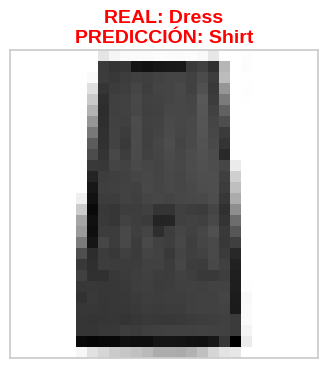

Predicción del índice 42: Shirt (Etiqueta Real: Dress)


In [ ]:
# Importar la librería random para elegir un ejemplo al azar
import random

# Seleccionar un índice de imagen al azar
i = random.randint(0, len(test_images) - 1)

# Extraer la imagen, la etiqueta verdadera y la etiqueta predicha
img = test_images[i]
true_label = true_labels[i]
predicted_label = predicted_labels[i]

# Determinar el color del texto (Verde para acierto, Rojo para error)
color = 'green' if predicted_label == true_label else 'red'

# Crear la figura y el subtítulo
plt.figure(figsize=(4,4))
plt.grid(False)
plt.xticks([])
plt.yticks([])

# Mostrar la imagen (usamos np.squeeze para eliminar la dimensión extra del canal)
plt.imshow(np.squeeze(img), cmap=plt.cm.binary)

title_text = f"REAL: {class_names[true_label]}\nPREDICCIÓN: {class_names[predicted_label]}"
plt.title(title_text, color=color, fontsize=14, fontweight='bold')

plt.show()
print(f"Predicción del índice {i}: {class_names[predicted_label]} (Etiqueta Real: {class_names[true_label]})")

Preparar los datos (aplanado para PyCaret)

In [ ]:
import pandas as pd

# Aplanar imágenes: (N,28,28,1) → (N, 784)
X_train_flat = train_images.reshape(len(train_images), -1)
X_test_flat = test_images.reshape(len(test_images), -1)

df_train = pd.DataFrame(X_train_flat)
df_train['label'] = train_labels

df_test = pd.DataFrame(X_test_flat)
df_test['label'] = test_labels

df_train.head()


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,9
1,0.0,0.0,0.0,0.0,0.0,0.003922,0.0,0.0,0.000000,0.000000,...,0.447059,0.509804,0.298039,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.086275,...,0.000000,0.003922,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.129412,0.376471,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,3
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0


Configurar PyCaret y generar el mejor modelo

In [ ]:
from pycaret.classification import *

exp = setup(data=df_train, target='label', session_id=123, verbose=False)

best_model = compare_models(exclude = ['lr', 'knn', 'sgd', 'mlp', 'catboost', 'lightgbm', 'gbc'], fold=3)
best_model

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.8611,0.9882,0.8611,0.8609,0.8601,0.8457,0.8459,83.3533
et,Extra Trees Classifier,0.8464,0.9857,0.8464,0.8454,0.8446,0.8294,0.8297,3.1267
rf,Random Forest Classifier,0.8450,0.9857,0.8450,0.8444,0.8429,0.8278,0.8282,5.8400
svm,SVM - Linear Kernel,0.7976,0.0000,0.7976,0.8010,0.7947,0.7751,0.7763,2.7967
lda,Linear Discriminant Analysis,0.7930,0.0000,0.7930,0.7955,0.7935,0.7700,0.7701,1.2667
ridge,Ridge Classifier,0.7921,0.0000,0.7921,0.7896,0.7892,0.7691,0.7695,0.5967
dt,Decision Tree Classifier,0.7400,0.8556,0.7400,0.7420,0.7405,0.7111,0.7112,2.8633
nb,Naive Bayes,0.5286,0.8771,0.5286,0.5903,0.4869,0.4760,0.4943,3.9067
ada,Ada Boost Classifier,0.3903,0.0000,0.3903,0.4279,0.3550,0.3224,0.3410,7.5167
qda,Quadratic Discriminant Analysis,0.1933,0.0000,0.1933,0.2306,0.1781,0.1041,0.1068,2.7933


Processing:   0%|          | 0/37 [00:00<?, ?it/s]

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)

Evaluar PyCaret en test

In [ ]:
pred_pycaret = predict_model(best_model, data=df_test)

from sklearn.metrics import accuracy_score

acc_pycaret = accuracy_score(df_test['label'], pred_pycaret['prediction_label'])
print("Accuracy PyCaret:", acc_pycaret)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.8558,0.9866,0.8558,0.8561,0.8555,0.8397,0.8398


Accuracy PyCaret: 0.8558


Comparar CNN vs PyCaret (gráfico simple)

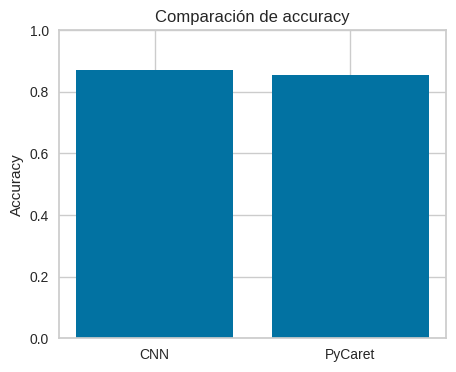

In [ ]:
import matplotlib.pyplot as plt

acc_cnn = test_acc

plt.figure(figsize=(5,4))
plt.bar(['CNN', 'PyCaret'], [acc_cnn, acc_pycaret])
plt.ylabel("Accuracy")
plt.title("Comparación de accuracy")
plt.ylim(0,1)
plt.show()

Matriz de confusión CNN

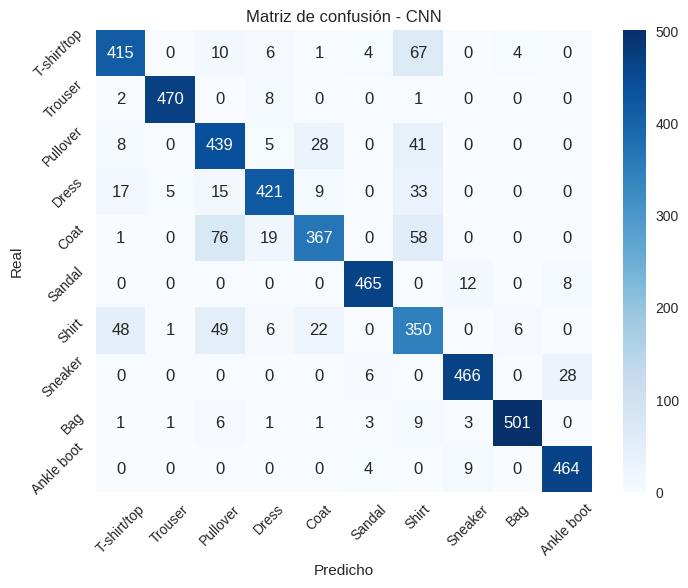

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_cnn = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de confusión - CNN")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

Matriz de confusión PyCaret

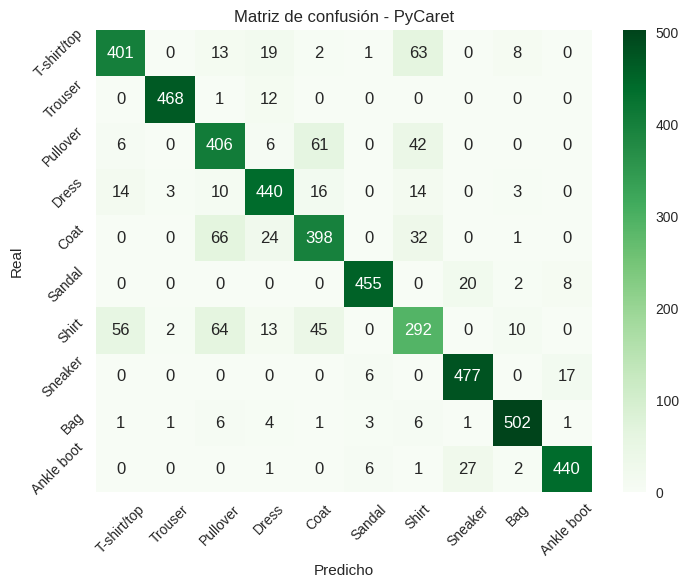

In [ ]:
y_true = df_test['label']
y_pred = pred_pycaret['prediction_label']

cm_py = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_py, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de confusión - PyCaret")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

Predicción final comparando ambos modelos con una imagen al azar

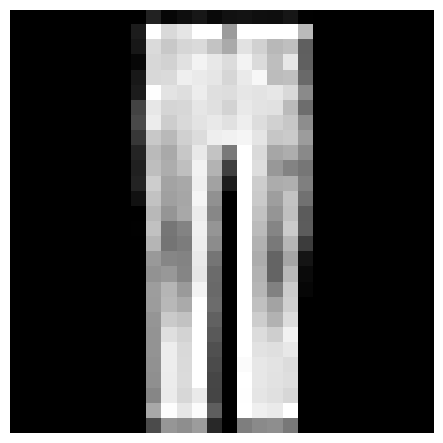

Etiqueta real: Trouser
Predicción CNN: Trouser
Predicción PyCaret: Trouser


In [ ]:
import random
i = random.randint(0, len(test_images)-1)

# Mostrar imagen
plt.imshow(np.squeeze(test_images[i]), cmap='gray')
plt.axis('off')
plt.show()

# CNN
cnn_pred = predicted_labels[i]

# PyCaret
fila = df_test.drop(columns=['label']).iloc[i:i+1]
pycaret_pred = predict_model(best_model, data=fila)['prediction_label'].iloc[0]

print("Etiqueta real:", class_names[true_labels[i]])
print("Predicción CNN:", class_names[cnn_pred])
print("Predicción PyCaret:", class_names[pycaret_pred])